In [1]:
%load_ext autoreload
%autoreload 2
import os

# I believe this environment variable should be set before importing t
os.environ["PYt_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch as t
from transformers import AutoModelForCausalLM, AutoTokenizer
import argparse
import itertools
import random
import json
import torch.multiprocessing as mp
import time
import huggingface_hub
from datasets import config
from transformers import AutoTokenizer
import demo_config
from tqdm import tqdm
import matplotlib.pyplot as plt

# Kind of janky double importing dictionary_learning.dictionary_learning, but it works
# This is leftover from when dictionary_learning was a only used as a submodule
from dictionary_learning.dictionary_learning.utils import (
    hf_dataset_to_generator,
    hf_mixed_dataset_to_generator,
    hf_sequence_packing_dataset_to_generator,
)
from dictionary_learning.dictionary_learning.pytorch_buffer import ActivationBuffer
from dictionary_learning.dictionary_learning.evaluation import evaluate
from dictionary_learning.dictionary_learning.training import trainSAE
import dictionary_learning.dictionary_learning.utils as utils


if os.path.exists('/u/eboix/moe_distillation/sae_demo'):
    os.chdir('/u/eboix/moe_distillation/sae_demo')

In [2]:
sae_dir = '._saes_EleutherAI_pythia-70m-deduped_top_k/mlp_in_3/trainer_0/'
device = t.device('cuda' if t.cuda.is_available() else 'cpu')
n_test_batches = 100

In [3]:
# load config.json from sae_dir
config_path = os.path.join(sae_dir, 'config.json')
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
else:
    assert(False), f'Config file not found at {config_path}'

model_name = config_data['trainer']['lm_name']
layer_idx = config_data['trainer']['layer']
io = config_data['buffer']['io']
dtype = t.float32

# load autoencoder from sae_file
from dictionary_learning.dictionary_learning.trainers.top_k import AutoEncoderTopK
ae_file = os.path.join(sae_dir, 'ae.pt')
autoencoder = AutoEncoderTopK.from_pretrained(ae_file)
autoencoder = autoencoder.to(device)
autoencoder.eval()
print('Autoencoder loaded from:', ae_file)

model = AutoModelForCausalLM.from_pretrained(
    model_name, device_map="auto", torch_dtype=dtype
)

model = utils.truncate_model(model, layer_idx)
model.eval()
model = model.to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
submodule = utils.get_submodule(model, layer_idx).mlp
submodule = submodule.to(device)
print('Model loaded:', model_name)

generator = hf_dataset_to_generator("monology/pile-uncopyrighted", 
    data_files={"validation": "val.jsonl.zst"},
    split="validation",)

activation_dim = config_data["trainer"]["activation_dim"]

activation_buffer = ActivationBuffer(
    generator,
    model,
    submodule,
    n_ctxs=config_data['buffer']['n_ctxs'],
    ctx_len=config_data['buffer']['ctx_len'],
    refresh_batch_size=config_data['buffer']['refresh_batch_size'],
    out_batch_size=config_data['buffer']['out_batch_size'],
    io=io,
    d_submodule=activation_dim,
    device=device,
)

print('Initialized activation buffer')

Autoencoder loaded from: ._saes_EleutherAI_pythia-70m-deduped_top_k/mlp_in_3/trainer_0/ae.pt
Model parameters before truncation: 70,426,624
Model parameters after truncation: 38,366,208
Model loaded: EleutherAI/pythia-70m-deduped
Initialized activation buffer


In [4]:
# Estimate variance of y_teacher
# first estimate mean
n_estimate_iters = 4
y_mean = t.zeros(activation_dim, device=device)
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = submodule(x)
    y_mean += y_teacher.mean(dim=0)
y_mean /= n_estimate_iters

y_variance = 0.0
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = submodule(x)
    y_variance += t.mean(t.mean((y_teacher - y_mean) ** 2, dim=0))
y_variance /= n_estimate_iters
y_variance = y_variance.item()
print('Variance in y', y_variance)


  0%|                                                                                                                                                                                                                                                    | 0/4 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 274.29it/s]

Variance in y 0.17686313390731812


In [5]:
# # MLP class for experts
# class LowRankExpert(t.nn.Module):
#     def __init__(self, d, rank, d_hidden):
#         super(LowRankExpert, self).__init__()
#         self.fc1 = t.nn.Linear(d, rank)
#         self.fc2 = t.nn.Linear(rank, d_hidden)

#     def forward(self, x):
#         x = self.fc1(x)
#         x = self.fc2(x)
#         return x

# # Mixture of experts model class
# # with m experts, each of which is an MLP of width d_expert, of which k are active, given by a top-k gating function on linear routing
# class MoELowRankModel(t.nn.Module):
#     def __init__(self, d, d_hidden, d_expert, m, k):
#         super(MoELowRankModel, self).__init__()
#         self.d = d
#         self.d_expert = d_expert
#         self.m = m
#         self.k = k
#         self.gate = t.nn.Linear(d,m)
#         self.experts1 = t.nn.Parameter(t.randn(m, d, d_expert))
#         self.experts2 = t.nn.Parameter(t.randn(m, d_expert, d_hidden))
#         self.expert_biases = t.nn.Parameter(t.zeros(m, d_hidden))
#         self.hidden_bias = t.nn.Parameter(t.zeros(d_hidden))
#         self.fc2 = t.nn.Linear(d_hidden, d)

#     def forward(self, x):
#         # Compute gating scores
#         gate_scores = self.gate(x)
#         # Select top-k experts
#         top_k_experts = gate_scores.topk(self.k, dim=1)
#         top_k_indices = top_k_experts.indices  # Shape: [batch_size, k]
#         top_k_values = top_k_experts.values  # Shape: [batch_size, k]
#         # compute softmax of top_k_values
#         top_k_softmax = t.nn.functional.softmax(top_k_values, dim=1)
#         print('top_k_softmax shape:', top_k_softmax.shape)
#         print(top_k_softmax)

#         # for each batch index i, compute the 

#         # for each batch index i, compute the biases from the top-k experts
#         # biases[i,:] = hidden_bias[i,:] + sum_{j=1}^k self.expert_biases[i,top_k_indices[i,j]]]
#         biases = self.hidden_bias.unsqueeze(0) + t.sum(
#             self.expert_biases[top_k_indices], dim=1
#         )
#         print('biases shape:', biases.shape)
#         assert(False)


In [6]:
class ParallelMoEWithRotationNaive(t.nn.Module):
    def __init__(self, d, d_hidden, d_expert, m, k):
        super(ParallelMoEWithRotationNaive, self).__init__()
        self.d = d
        self.d_expert = d_expert
        assert(d_expert == 1), "NaiveMoELowRankModel only supports d_expert = 1"
        self.m = m
        self.k = k
        self.experts1 = t.nn.Linear(d,m)
        self.experts2 = t.nn.Linear(m, d_hidden)
        self.experts2.weight.requires_grad = False
        self.fc2 = t.nn.Linear(d_hidden, d)

    def forward(self, x):
        x = self.experts1(x)  # Shape: [batch_size, m]
        # zero out all but the top-k entries of x
        top_k_values, top_k_indices = x.topk(self.k, dim=1)
        x = t.zeros_like(x)
        x.scatter_(1, top_k_indices, top_k_values)
        x = self.experts2(x)
        # nonlinear gelu activation
        x = t.nn.functional.gelu(x)
        # apply fc2 to get back to original dimension
        x = self.fc2(x)
        return x

In [7]:
class NaiveMoELowRankModel(t.nn.Module):
    def __init__(self, d, d_hidden, d_expert, m, k):
        super(NaiveMoELowRankModel, self).__init__()
        self.d = d
        self.d_expert = d_expert
        assert(d_expert == 1), "NaiveMoELowRankModel only supports d_expert = 1"
        self.m = m
        self.k = k
        self.experts1 = t.nn.Linear(d,m)
        self.experts2 = t.nn.Linear(m, d_hidden)
        self.fc2 = t.nn.Linear(d_hidden, d)

    def forward(self, x):
        x = self.experts1(x)  # Shape: [batch_size, m]
        # zero out all but the top-k entries of x
        top_k_values, top_k_indices = x.topk(self.k, dim=1)
        x = t.zeros_like(x)
        x.scatter_(1, top_k_indices, top_k_values)
        x = self.experts2(x)
        # nonlinear gelu activation
        x = t.nn.functional.gelu(x)
        # apply fc2 to get back to original dimension
        x = self.fc2(x)
        return x

In [8]:
from tqdm.notebook import tqdm

# train NaiveMoeLowRankModel as student model to learn submodule

device = activation_buffer.device
d = activation_buffer.d_submodule
d_hidden = d*4

# m=16384
m=512
k=40
num_tokens = 50_000_000
batch_size = activation_buffer.out_batch_size
num_batches = num_tokens // batch_size

# student_model = ParallelMoEWithRotationNaive(d, d_hidden, d_expert=1, m=m, k=k).to(device)
student_model = NaiveMoELowRankModel(d, d_hidden, d_expert=1, m=m, k=k).to(device)
# Create parameter groups with different learning rates
optimizer = t.optim.AdamW([
    {'params': student_model.experts1.parameters(), 'lr': 3e-4},
    {'params': student_model.experts2.bias, 'lr': 3e-4},
    {'params': student_model.fc2.parameters(), 'lr': 3e-4}
])
# Set up a cosine learning rate scheduler
scheduler = t.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_batches, eta_min=1e-5)
# Training loop
criterion = t.nn.MSELoss()
losses = []

progress_bar = tqdm(range(num_batches), desc="Training Student Model")

for i in progress_bar:
    # Get a batch of input activations
    x_batch = next(activation_buffer).to(device)
    
    # Get the target outputs by passing through the original submodule
    with t.no_grad():
        target_output = submodule(x_batch)
    
    # Forward pass through student model
    student_output = student_model(x_batch)
    
    # Compute loss
    loss = criterion(student_output, target_output)
    variance_explained = 1 - (loss.item() / y_variance)
    progress_bar.set_postfix({"loss": f"{loss.item():.6f}", "variance_explained": f"{variance_explained:.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

Training Student Model:   0%|          | 0/24414 [00:00<?, ?it/s]

# Teacher is random MLP on isotropic Gaussian data

In [9]:
class MLP(t.nn.Module):
    def __init__(self, d_in=256, d_hidden=1024, d_out=256):
        super(MLP, self).__init__()
        self.fc1 = t.nn.Linear(d_in, d_hidden)
        self.fc2 = t.nn.Linear(d_hidden, d_out)
        self.activation = t.nn.GELU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

In [11]:
from tqdm.notebook import tqdm

# train NaiveMoeLowRankModel as student model to learn submodule

device = activation_buffer.device
d = activation_buffer.d_submodule
d_hidden = d*4
batch_size = activation_buffer.out_batch_size


## Set up random teacher, and compute variance
random_teacher_mlp = MLP(d_in=d,d_hidden=d_hidden,d_out=d).to(device)

x_batch = next(activation_buffer).to(device)
x_mean = t.mean(x_batch,dim=0)
x_batch = next(activation_buffer).to(device)
avg_std = t.sqrt(t.mean((x_batch - x_mean)**2))

# Estimate variance of y_teacher
# first estimate mean
n_estimate_iters = 10
y_mean = t.zeros(activation_dim, device=device)
for _ in tqdm(range(n_estimate_iters)):
    # x = next(activation_buffer)
    x = t.randn(batch_size, d, device=device) * avg_std + x_mean
    x = x.to(device)
    y_teacher = random_teacher_mlp(x)
    y_mean += y_teacher.mean(dim=0)
y_mean /= n_estimate_iters

y_variance = 0.0
for _ in tqdm(range(n_estimate_iters)):
    # x = next(activation_buffer)
    x = t.randn(batch_size, d, device=device) * avg_std + x_mean
    x = x.to(device)
    y_teacher = random_teacher_mlp(x)
    y_variance += t.mean(t.mean((y_teacher - y_mean) ** 2, dim=0))
y_variance /= n_estimate_iters
y_variance = y_variance.item()
print('Variance in y', y_variance)

m=16384
k=40
num_tokens = 50_000_000
batch_size = activation_buffer.out_batch_size
num_batches = num_tokens // batch_size

student_model = NaiveMoELowRankModel(d, d_hidden, d_expert=1, m=m, k=k).to(device)
optimizer = t.optim.AdamW(student_model.parameters(), lr=3e-4)
# Set up a cosine learning rate scheduler
scheduler = t.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_batches, eta_min=1e-5)
# Training loop
criterion = t.nn.MSELoss()
losses = []

progress_bar = tqdm(range(num_batches), desc="Training Student Model")

for i in progress_bar:
    # Get a batch of input activations
    # x_batch = next(activation_buffer).to(device)
    x_batch = t.randn(batch_size, d, device=device) * avg_std + x_mean
    
    # Get the target outputs by passing through the original submodule
    with t.no_grad():
        target_output = random_teacher_mlp(x_batch)
    
    # Forward pass through student model
    student_output = student_model(x_batch)
    
    # Compute loss
    loss = criterion(student_output, target_output)
    variance_explained = 1 - (loss.item() / y_variance)
    progress_bar.set_postfix({"loss": f"{loss.item():.6f}", "variance_explained": f"{variance_explained:.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Variance in y 0.05163949355483055


Training Student Model:   0%|          | 0/24414 [00:00<?, ?it/s]

# Teacher is random MLP on activation data

In [12]:
from tqdm.notebook import tqdm

# train NaiveMoeLowRankModel as student model to learn submodule

device = activation_buffer.device
d = activation_buffer.d_submodule
d_hidden = d*4


## Set up random teacher, and compute variance
random_teacher_mlp = MLP(d_in=d,d_hidden=d_hidden,d_out=d).to(device)

# Estimate variance of y_teacher
# first estimate mean
n_estimate_iters = 4
y_mean = t.zeros(activation_dim, device=device)
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = random_teacher_mlp(x)
    y_mean += y_teacher.mean(dim=0)
y_mean /= n_estimate_iters

y_variance = 0.0
for _ in tqdm(range(n_estimate_iters)):
    x = next(activation_buffer)
    x = x.to(device)
    y_teacher = random_teacher_mlp(x)
    y_variance += t.mean(t.mean((y_teacher - y_mean) ** 2, dim=0))
y_variance /= n_estimate_iters
y_variance = y_variance.item()
print('Variance in y', y_variance)

m=16384
k=40
num_tokens = 50_000_000
batch_size = activation_buffer.out_batch_size
num_batches = num_tokens // batch_size

student_model = NaiveMoELowRankModel(d, d_hidden, d_expert=1, m=m, k=k).to(device)
optimizer = t.optim.AdamW(student_model.parameters(), lr=3e-4)
# Set up a cosine learning rate scheduler
scheduler = t.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_batches, eta_min=1e-5)
# Training loop
criterion = t.nn.MSELoss()
losses = []

progress_bar = tqdm(range(num_batches), desc="Training Student Model")

for i in progress_bar:
    # Get a batch of input activations
    x_batch = next(activation_buffer).to(device)
    
    # Get the target outputs by passing through the original submodule
    with t.no_grad():
        target_output = random_teacher_mlp(x_batch)
    
    # Forward pass through student model
    student_output = student_model(x_batch)
    
    # Compute loss
    loss = criterion(student_output, target_output)
    variance_explained = 1 - (loss.item() / y_variance)
    progress_bar.set_postfix({"loss": f"{loss.item():.6f}", "variance_explained": f"{variance_explained:.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Variance in y 0.04946471005678177


Training Student Model:   0%|          | 0/24414 [00:00<?, ?it/s]

In [13]:
x_batch = next(activation_buffer).to(device)

In [27]:
encoded_acts = autoencoder.encoder(x_batch)

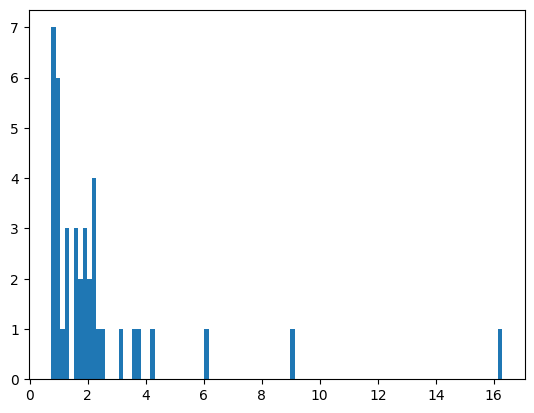

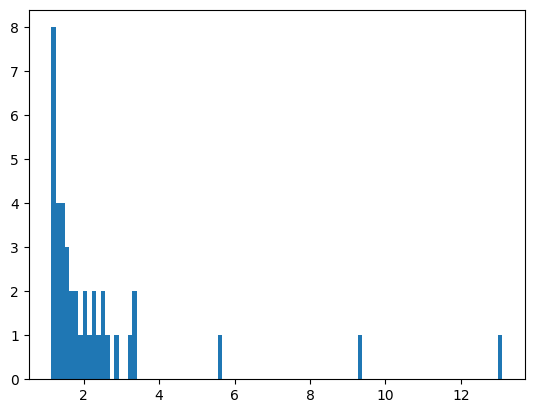

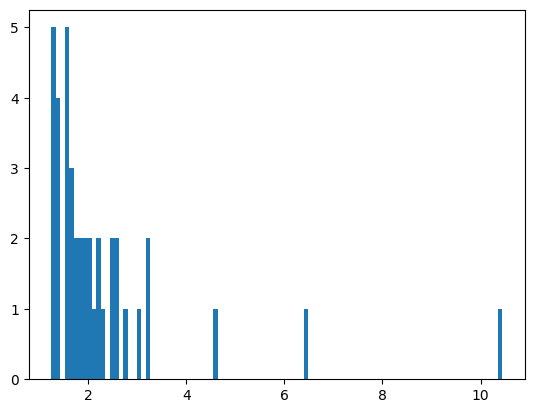

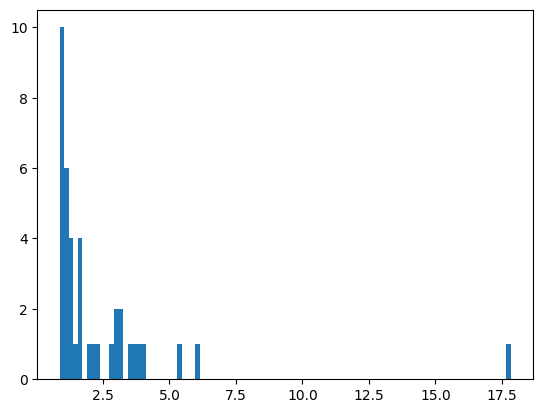

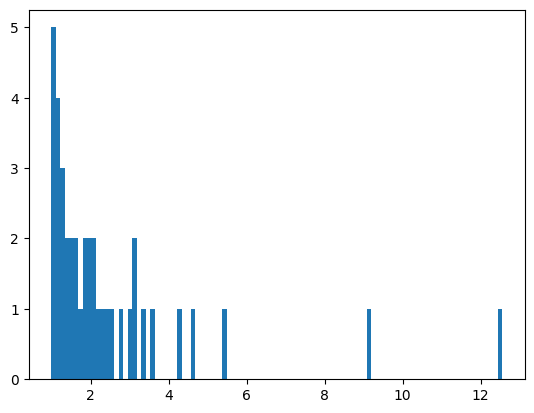

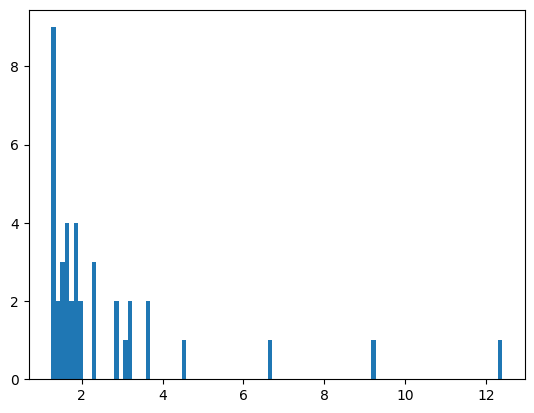

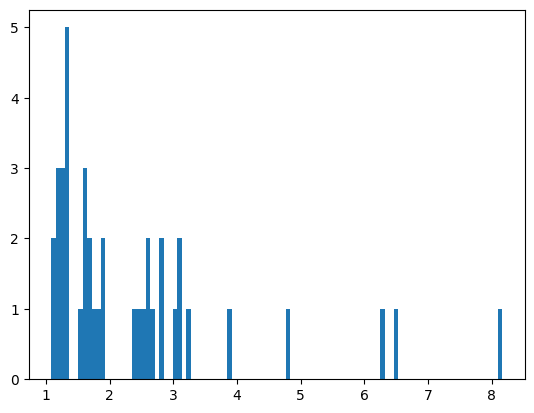

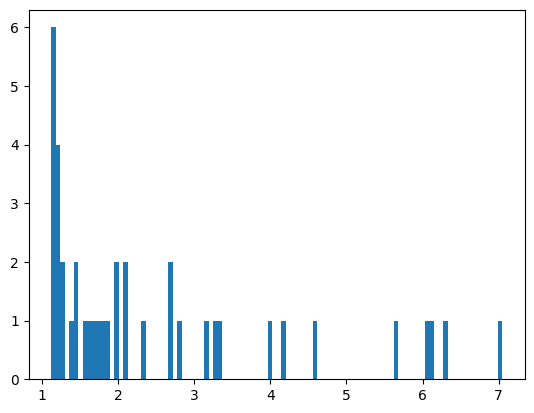

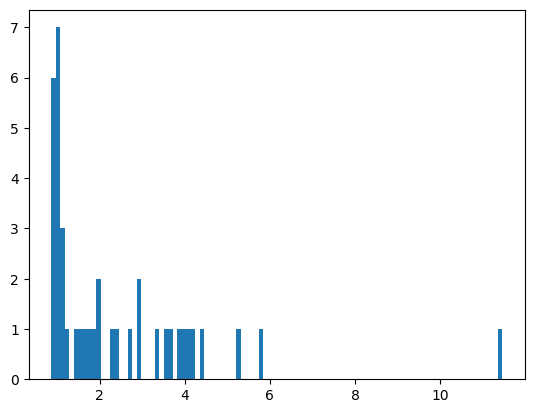

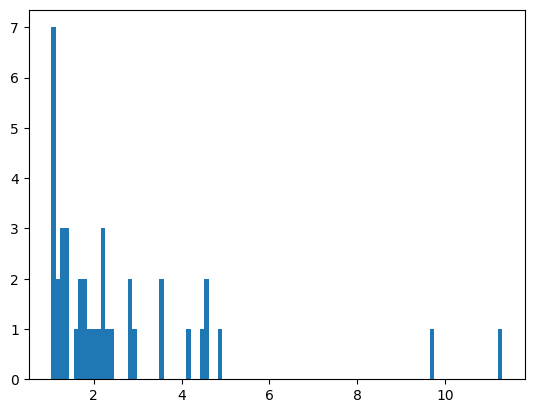

In [33]:
for i in range(10):
    topk_vals = encoded_acts[i,:].topk(40).values
    plt.hist(topk_vals.cpu().detach().numpy(), bins=100)
    plt.show()

Cutoff for top-k 0: 0.7403753995895386


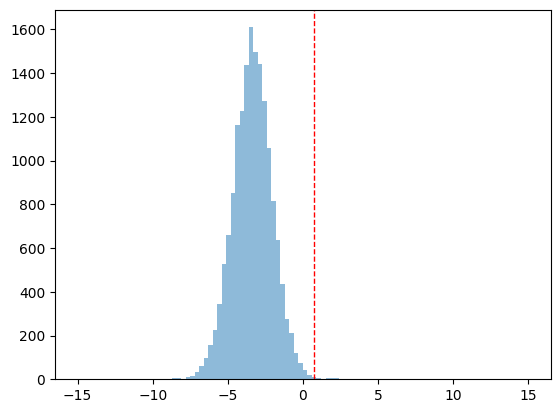

Cutoff for top-k 1: 1.1414095163345337


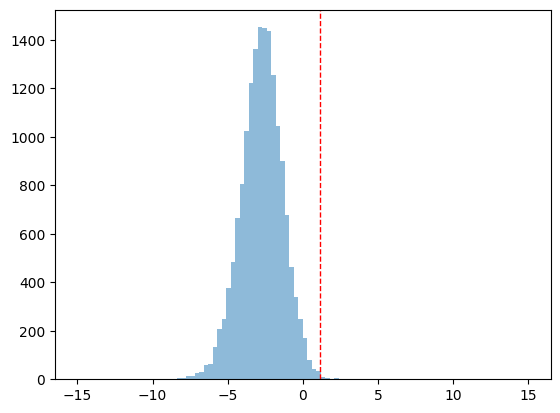

Cutoff for top-k 2: 1.2476714849472046


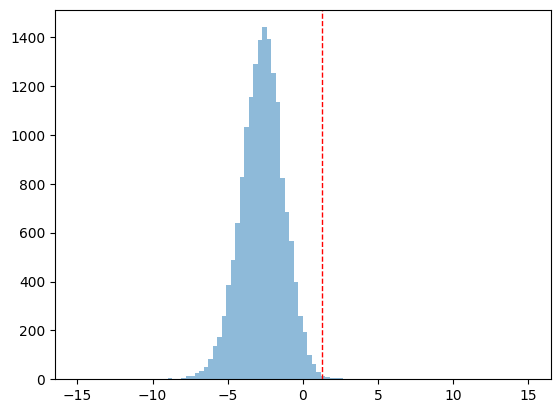

Cutoff for top-k 3: 0.8828423023223877


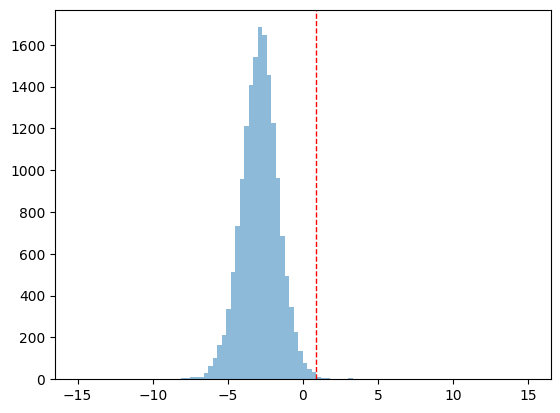

Cutoff for top-k 4: 0.9822071194648743


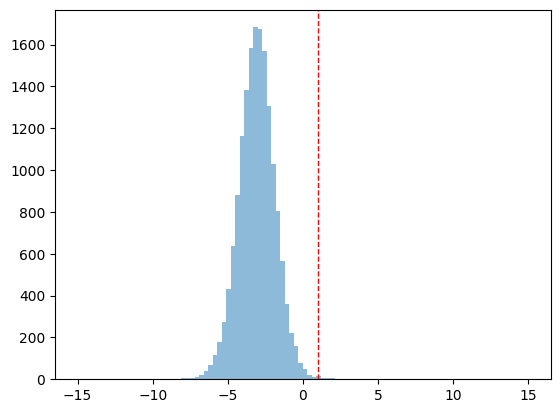

Cutoff for top-k 5: 1.2431230545043945


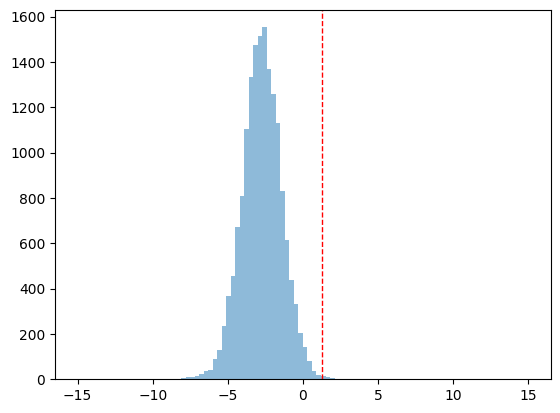

Cutoff for top-k 6: 1.0808008909225464


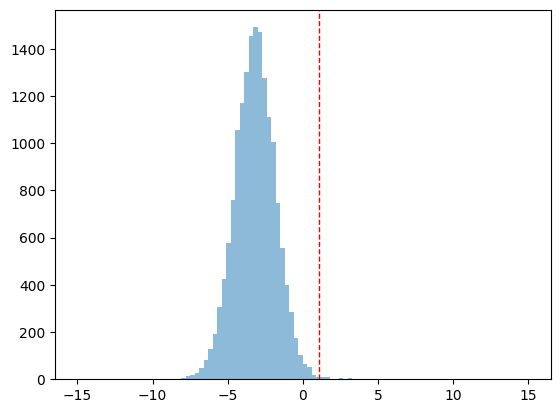

Cutoff for top-k 7: 1.1211601495742798


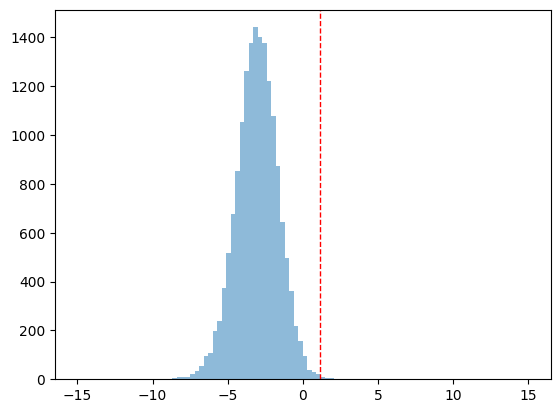

Cutoff for top-k 8: 0.8591628074645996


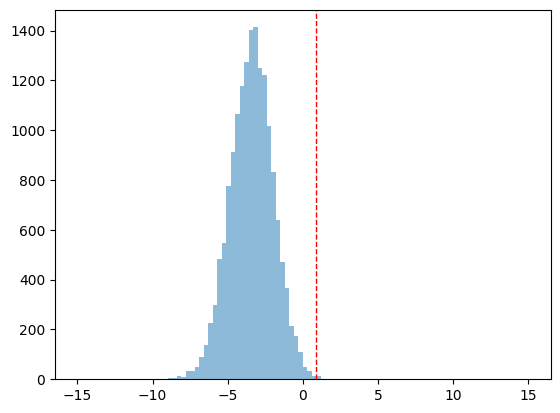

Cutoff for top-k 9: 1.0316087007522583


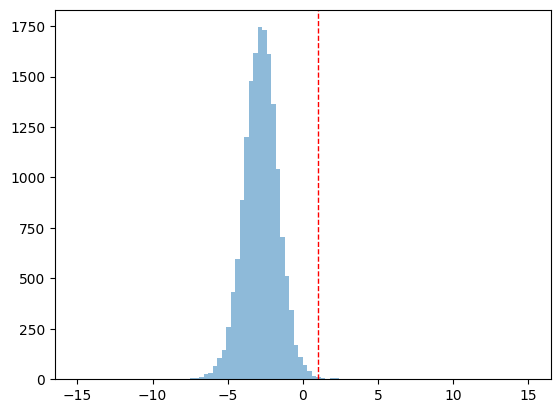

In [38]:
for i in range(10):
    topk_vals = encoded_acts[i,:].topk(40).values
    cutoff = topk_vals.min().item()
    print(f'Cutoff for top-k {i}: {cutoff}')
    # plt.hist(topk_vals.cpu().detach().numpy(), bins=100, alpha=0.5, range=(-15,15))
    plt.hist(encoded_acts[i,:].cpu().detach().numpy(), bins=100, alpha=0.5, range=(-15,15))
    plt.axvline(cutoff, color='red', linestyle='dashed', linewidth=1)
    plt.show()

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 3.000e+00,
        1.700e+01, 3.300e+01, 1.200e+02, 5.740e+02, 2.093e+03, 4.622e+03,
        4.860e+03, 2.489e+03, 8.360e+02, 3.260e+02, 2.060e+02, 7.900e+01,
        5.600e+01, 6.000e+01, 3.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

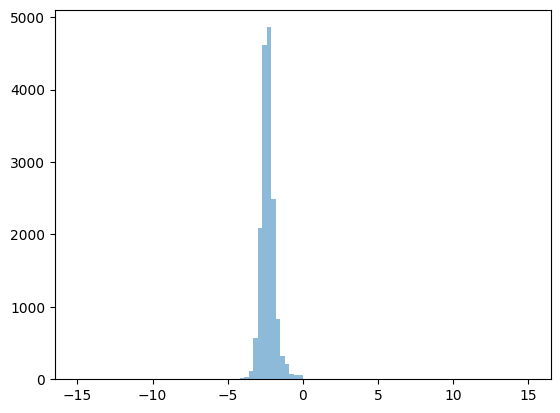

In [40]:
plt.hist(autoencoder.encoder.bias.data.detach().cpu().numpy(), bins=100, alpha=0.5, range=(-15,15))